In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
nifty50 = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","ICICIBANK.NS","INFY.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS","SUNPHARMA.NS",
"TITAN.NS","ULTRACEMCO.NS","NESTLEIND.NS","BAJFINANCE.NS","BAJAJFINSV.NS"
]

In [4]:
data = yf.download(nifty50, period="6mo",threads=False)
close = data['Close']

close.head()

[*********************100%***********************]  20 of 20 completed


Ticker,ASIANPAINT.NS,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,NESTLEIND.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,
2025-10-15,2371.399170,1169.599976,2084.100098,1059.900024,1968.500000,978.250000,2499.352539,1398.400024,1452.169067,391.691071,429.920013,3828.699951,16212.0,1214.840942,1374.300049,886.099976,1644.418213,2916.776367,3549.000000,12311.0
2025-10-16,2405.945068,1196.300049,2090.199951,1065.750000,1967.400024,994.349976,2541.520996,1417.300049,1449.312744,396.833313,441.079987,3861.800049,16298.0,1269.744507,1398.300049,886.950012,1648.292969,2917.660156,3640.300049,12358.0
2025-10-17,2503.892334,1200.199951,2083.699951,1070.099976,2012.000000,1002.549988,2583.391846,1436.599976,1419.371094,403.689606,441.160004,3839.399902,16401.0,1282.575195,1416.800049,889.150024,1668.263306,2909.311768,3674.800049,12370.0
2025-10-20,2512.079346,1226.000000,2139.800049,1081.000000,2051.500000,1002.950012,2574.164307,1390.300049,1438.872559,404.571136,442.760010,3872.699951,16424.0,1278.497192,1466.800049,907.500000,1677.702026,2961.365479,3737.199951,12346.0
2025-10-21,2500.697266,1237.300049,2169.100098,1086.500000,2043.500000,1007.700012,2571.485596,1382.000000,1450.199219,404.375275,439.399994,3888.199951,16396.0,1280.387085,1465.199951,907.849976,1679.589722,2953.017334,3729.000000,12342.0


In [5]:
returns = close.pct_change().dropna()
returns.head()


Ticker,ASIANPAINT.NS,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,NESTLEIND.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,
2025-10-16,0.014568,0.022828,0.002927,0.005519,-0.000559,0.016458,0.016872,0.013515,-0.001967,0.013128,0.025958,0.008645,0.005305,0.045194,0.017463,0.000959,0.002356,0.000303,0.025726,0.003818
2025-10-17,0.040711,0.003260,-0.003110,0.004082,0.022670,0.008247,0.016475,0.013617,-0.020659,0.017278,0.000181,-0.005800,0.006320,0.010105,0.013230,0.002480,0.012116,-0.002861,0.009477,0.000971
2025-10-20,0.003270,0.021496,0.026923,0.010186,0.019632,0.000399,-0.003572,-0.032229,0.013740,0.002184,0.003627,0.008673,0.001402,-0.003180,0.035291,0.020638,0.005658,0.017892,0.016980,-0.001940
2025-10-21,-0.004531,0.009217,0.013693,0.005088,-0.003900,0.004736,-0.001041,-0.005970,0.007872,-0.000484,-0.007589,0.004002,-0.001705,0.001478,-0.001091,0.000386,0.001125,-0.002819,-0.002194,-0.000324
2025-10-23,-0.000878,0.017377,0.003458,0.007041,-0.017421,0.001092,0.003820,-0.013242,0.038101,0.007509,0.013018,0.007844,-0.000183,-0.011264,-0.011466,0.004076,-0.000355,0.022117,0.011612,-0.015962


In [6]:
def moving_avg(df):
    return df.rolling(50).mean()

In [7]:
def compute_rsi(df):
    delta = df.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    
    rs = gain / loss
    return 100 - (100 / (1 + rs))

In [10]:
for stock in nifty50:
    df = yf.download(stock, period="1y", threads=False)

    if df.empty or len(df) < 50:
        continue

    df['MA50'] = df['Close'].rolling(50).mean()

    # RSI
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # single values
    price = df['Close'].iloc[-1].item()
    rsi = df['RSI'].iloc[-1].item()
    ma50 = df['MA50'].iloc[-1].item()

    # signal
    if price > ma50 and rsi < 70:
        signal = "BUY"
    elif price < ma50 and rsi > 30:
        signal = "SELL"
    else:
        signal = "HOLD"

    print(f"{stock} | Price: {round(price,2)} | RSI: {round(rsi,2)} | Signal: {signal}")
    
    results.append([stock, price, rsi, signal])

screener_df = pd.DataFrame(results, columns=["Stock","Price","RSI","Signal"])
screener_df

[*********************100%***********************]  1 of 1 completed


RELIANCE.NS | Price: 1340.5 | RSI: 38.18 | Signal: SELL


[*********************100%***********************]  1 of 1 completed


TCS.NS | Price: 2547.6 | RSI: 65.45 | Signal: SELL


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


BAJFINANCE.NS | Price: 913.5 | RSI: 61.65 | Signal: SELL


[*********************100%***********************]  1 of 1 completed

BAJAJFINSV.NS | Price: 1821.7 | RSI: 61.18 | Signal: SELL


,Stock,Price,RSI,Signal
0,RELIANCE.NS,1340.500000,38.183552,SELL
1,TCS.NS,2547.600098,65.452741,SELL
2,HDFCBANK.NS,811.450012,55.675580,SELL
3,ICICIBANK.NS,1346.400024,65.820817,BUY
4,INFY.NS,1305.699951,60.138433,SELL
5,HINDUNILVR.NS,2158.899902,60.095366,SELL
6,ITC.NS,302.200012,52.321981,SELL
7,SBIN.NS,1071.650024,52.416365,SELL
8,BHARTIARTL.NS,1858.400024,52.311172,SELL
9,KOTAKBANK.NS,381.250000,57.871875,SELL


In [11]:
buy = screener_df[screener_df['Signal'] == "BUY"]
sell = screener_df[screener_df['Signal'] == "SELL"]

buy

,Stock,Price,RSI,Signal
3,ICICIBANK.NS,1346.400024,65.820817,BUY
11,AXISBANK.NS,1350.000000,69.716602,BUY
12,ASIANPAINT.NS,2419.500000,65.180884,BUY
15,TITAN.NS,4517.200195,65.082271,BUY
17,NESTLEIND.NS,1256.800049,63.166675,BUY


<Axes: title={'center': 'Portfolio Performance'}, xlabel='Date'>

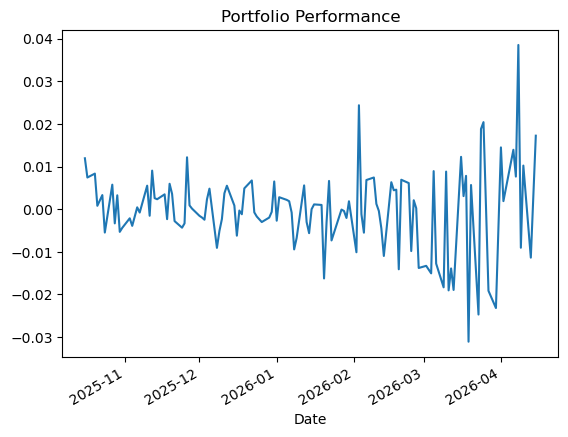

In [12]:
weights = [1/len(close.columns)] * len(close.columns)

portfolio = (returns * weights).sum(axis=1)

portfolio.plot(title="Portfolio Performance")